Jump times:
[0.0, 0.15642269665895303, 0.5953379278407694, 0.6518795513282182, 0.6668392434803884, 0.9731999613561432, 0.9783997883559278, 1.573876302807486, 1.640769299057374, 1.7314577314224933, 1.9199700870159389, 2.235427044982538, 2.3218059229831387, 2.5247841522697305, 2.580468117801903, 2.87963635823849, 3.19141403178836, 3.208230014508186, 4.331773461995244, 4.422595426987433, 4.8068456813536535, 4.839383739842265, 4.851048313656759, 4.92591275786693, 5.050428285086138, 5.31416955108007, 6.187371334264126, 7.12240280736132, 7.350166410457139, 7.381051563441511, 7.396478885337121, 7.519511458285676, 8.107697413365987, 8.217631693410736, 8.255606230365894, 8.281431519969663, 8.65130246403004, 8.653148270822019, 9.062180239951033, 9.430983871461912, 9.578948095600657]

Visited states:
[0, 2, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 0, 1, 2, 1, 0, 1, 2, 1, 2, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 1, 0, 2, 1, 0, 1]


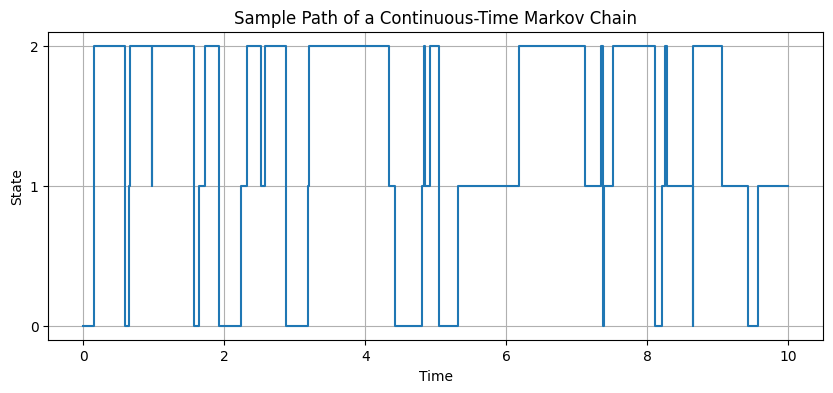

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Generator matrix Q
# -------------------------------
# Q[i,j] = rate of jumping from state i to state j
# Diagonal entries are negative so that each row sums to 0

Q = np.array([
    [-3.0,  2.0,  1.0],
    [ 1.0, -4.0,  3.0],
    [ 2.0,  1.0, -3.0]
])

# -------------------------------
# CTMC simulation function
# -------------------------------
def simulate_ctmc(Q, initial_state, T_max, seed=None):
    """
    Simulate a continuous-time Markov chain up to time T_max.

    Parameters:
        Q : generator matrix
        initial_state : starting state
        T_max : final simulation time
        seed : random seed

    Returns:
        times : jump times
        states : state occupied after each time in times
    """
    if seed is not None:
        np.random.seed(seed)

    n_states = Q.shape[0]
    t = 0.0
    state = initial_state

    times = [0.0]
    states = [state]

    while t < T_max:
        # Exit rate from current state
        rate = -Q[state, state]

        # Sample holding time ~ Exp(rate)
        holding_time = np.random.exponential(scale=1/rate)
        t_next = t + holding_time

        if t_next > T_max:
            break

        # Jump probabilities to other states
        probs = Q[state, :].copy()
        probs[state] = 0.0
        probs = probs / rate

        # Choose next state
        next_state = np.random.choice(n_states, p=probs)

        # Update
        t = t_next
        state = next_state

        times.append(t)
        states.append(state)

    return times, states


# -------------------------------
# Run simulation
# -------------------------------
T_max = 10
initial_state = 0

times, states = simulate_ctmc(Q, initial_state, T_max, seed=42)

print("Jump times:")
print(times)

print("\nVisited states:")
print(states)


# -------------------------------
# Build step-plot data
# -------------------------------
plot_times = []
plot_states = []

for i in range(len(times)):
    plot_times.append(times[i])
    plot_states.append(states[i])

    if i < len(times) - 1:
        plot_times.append(times[i+1])
        plot_states.append(states[i])

# Extend to T_max
plot_times.append(T_max)
plot_states.append(states[-1])

# -------------------------------
# Plot sample path
# -------------------------------
plt.figure(figsize=(10, 4))
plt.step(plot_times, plot_states, where='post')
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Sample Path of a Continuous-Time Markov Chain")
plt.yticks([0, 1, 2])
plt.grid(True)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_mm1_queue(lam, mu, T_max, initial_state=0, seed=None):
    """
    Simulate an M/M/1 queue as a continuous-time Markov chain.

    Parameters
    ----------
    lam : float
        Arrival rate lambda
    mu : float
        Service rate mu
    T_max : float
        Final simulation time
    initial_state : int
        Initial number of customers
    seed : int or None
        Random seed

    Returns
    -------
    times : list
        Jump times
    states : list
        Queue lengths at those times
    events : list
        Type of jump: 'arrival' or 'departure'
    """
    if seed is not None:
        np.random.seed(seed)

    t = 0.0
    n = initial_state

    times = [0.0]
    states = [n]
    events = []

    while t < T_max:
        if n == 0:
            # Only arrival possible
            total_rate = lam
            wait = np.random.exponential(1 / total_rate)
            if t + wait > T_max:
                break
            t += wait
            n += 1
            event = "arrival"
        else:
            # Both arrival and departure possible
            total_rate = lam + mu
            wait = np.random.exponential(1 / total_rate)
            if t + wait > T_max:
                break
            t += wait

            # Decide whether next jump is arrival or departure
            if np.random.rand() < lam / total_rate:
                n += 1
                event = "arrival"
            else:
                n -= 1
                event = "departure"

        times.append(t)
        states.append(n)
        events.append(event)

    return times, states, events


# Example parameters
lam = 2.0    # arrival rate
mu = 3.0     # service rate
T_max = 20.0

times, states, events = simulate_mm1_queue(lam, mu, T_max, initial_state=0, seed=42)

print("Jump times:")
print(times)

print("\nStates:")
print(states)

print("\nEvents:")
print(events)

Jump times:
[0.0, 0.23463404498842955, 0.8366583311719338, 1.2931296080599104, 1.3270545821523796, 1.3390223358741158, 1.5228387665995686, 1.5332384205991378, 2.2339499156308005, 2.353293728255274, 2.3934295260052068, 2.465980271897302, 2.5790876852533695, 2.768361860033329, 2.8374649624338097, 2.9592519000057647, 3.003799072431503, 3.183300016693455, 3.3703666208233773, 3.383819406999238, 4.057945475491473, 4.130603047485224, 4.361153200104956, 4.3871836468958465, 4.394182391184542, 4.5439112796048855, 4.761162439317881, 4.907984618499727, 4.948862338401308, 5.694985026970379, 6.256003910828695, 6.711531117020332, 7.221418192874213, 7.265045131800467, 7.343751549161085, 7.40706363780285, 7.495309037708823, 7.6517904543503725, 7.975887173505319, 8.842716441422782, 8.887024329523959, 9.225003685021184, 9.486136266778784, 9.501522119881542, 9.526152140802433, 9.721412379144907, 9.734545992305863, 9.813208834942689, 10.016186706727893, 10.143999933403155, 10.393825202266475, 10.5586027012

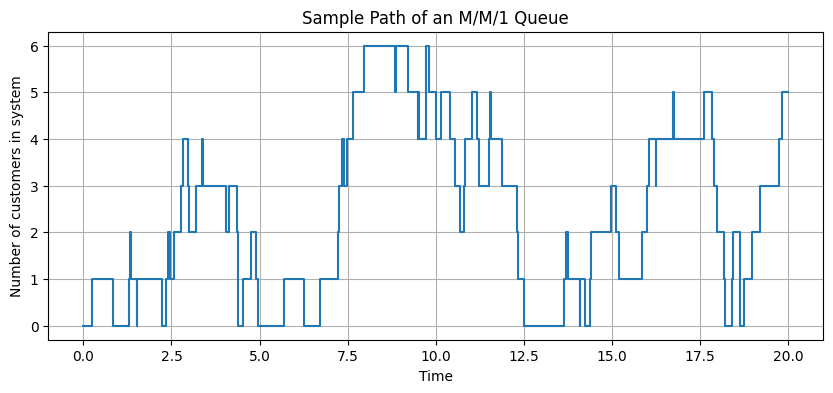

In [5]:
# Build data for a step plot
plot_times = []
plot_states = []

for i in range(len(times)):
    plot_times.append(times[i])
    plot_states.append(states[i])
    if i < len(times) - 1:
        plot_times.append(times[i + 1])
        plot_states.append(states[i])

plot_times.append(T_max)
plot_states.append(states[-1])

plt.figure(figsize=(10, 4))
plt.step(plot_times, plot_states, where='post')
plt.xlabel("Time")
plt.ylabel("Number of customers in system")
plt.title("Sample Path of an M/M/1 Queue")
plt.grid(True)
plt.show()

In [6]:
def estimate_state_proportions(times, states, T_max, max_state=None):
    """
    Estimate proportion of time spent in each state.
    """
    if max_state is None:
        max_state = max(states)

    durations = np.zeros(max_state + 1)

    for i in range(len(times) - 1):
        s = states[i]
        dt = times[i + 1] - times[i]
        if s <= max_state:
            durations[s] += dt

    # Add final segment up to T_max
    if states[-1] <= max_state:
        durations[states[-1]] += T_max - times[-1]

    return durations / T_max


props = estimate_state_proportions(times, states, T_max, max_state=10)

print("\nEstimated proportion of time in states 0 to 10:")
for i, p in enumerate(props):
    print(f"State {i}: {p:.4f}")


Estimated proportion of time in states 0 to 10:
State 0: 0.1878
State 1: 0.2339
State 2: 0.1181
State 3: 0.1546
State 4: 0.1558
State 5: 0.0857
State 6: 0.0642
State 7: 0.0000
State 8: 0.0000
State 9: 0.0000
State 10: 0.0000
